# 57 Insert Interval

## Problem Description
Given a non-overlapping interval list which is sorted by start point.
Insert a new interval into it, make sure the list is still in order and non-overlapping (merge intervals if necessary).

## Example

```
Input:
interval list = [(1,2), (5,9)]
new interval = (2, 5)
Output:[(1,9)]

Example 2:
Input:
interval list = [(1,2), (5,9)]
new interval = (3, 4)
Output:[(1,2), (3,4), (5,9)]

Intervals are ordered by starting endpoints.
```

## Complexity
- **Time**: O(n) - single pass
- **Space**: O(1) - only output

## Why Uber cares
- **Delivery time windows**: Adding new delivery slots
- **Driver availability**: Updating work schedules
- **Booking system**: Managing reservation slots

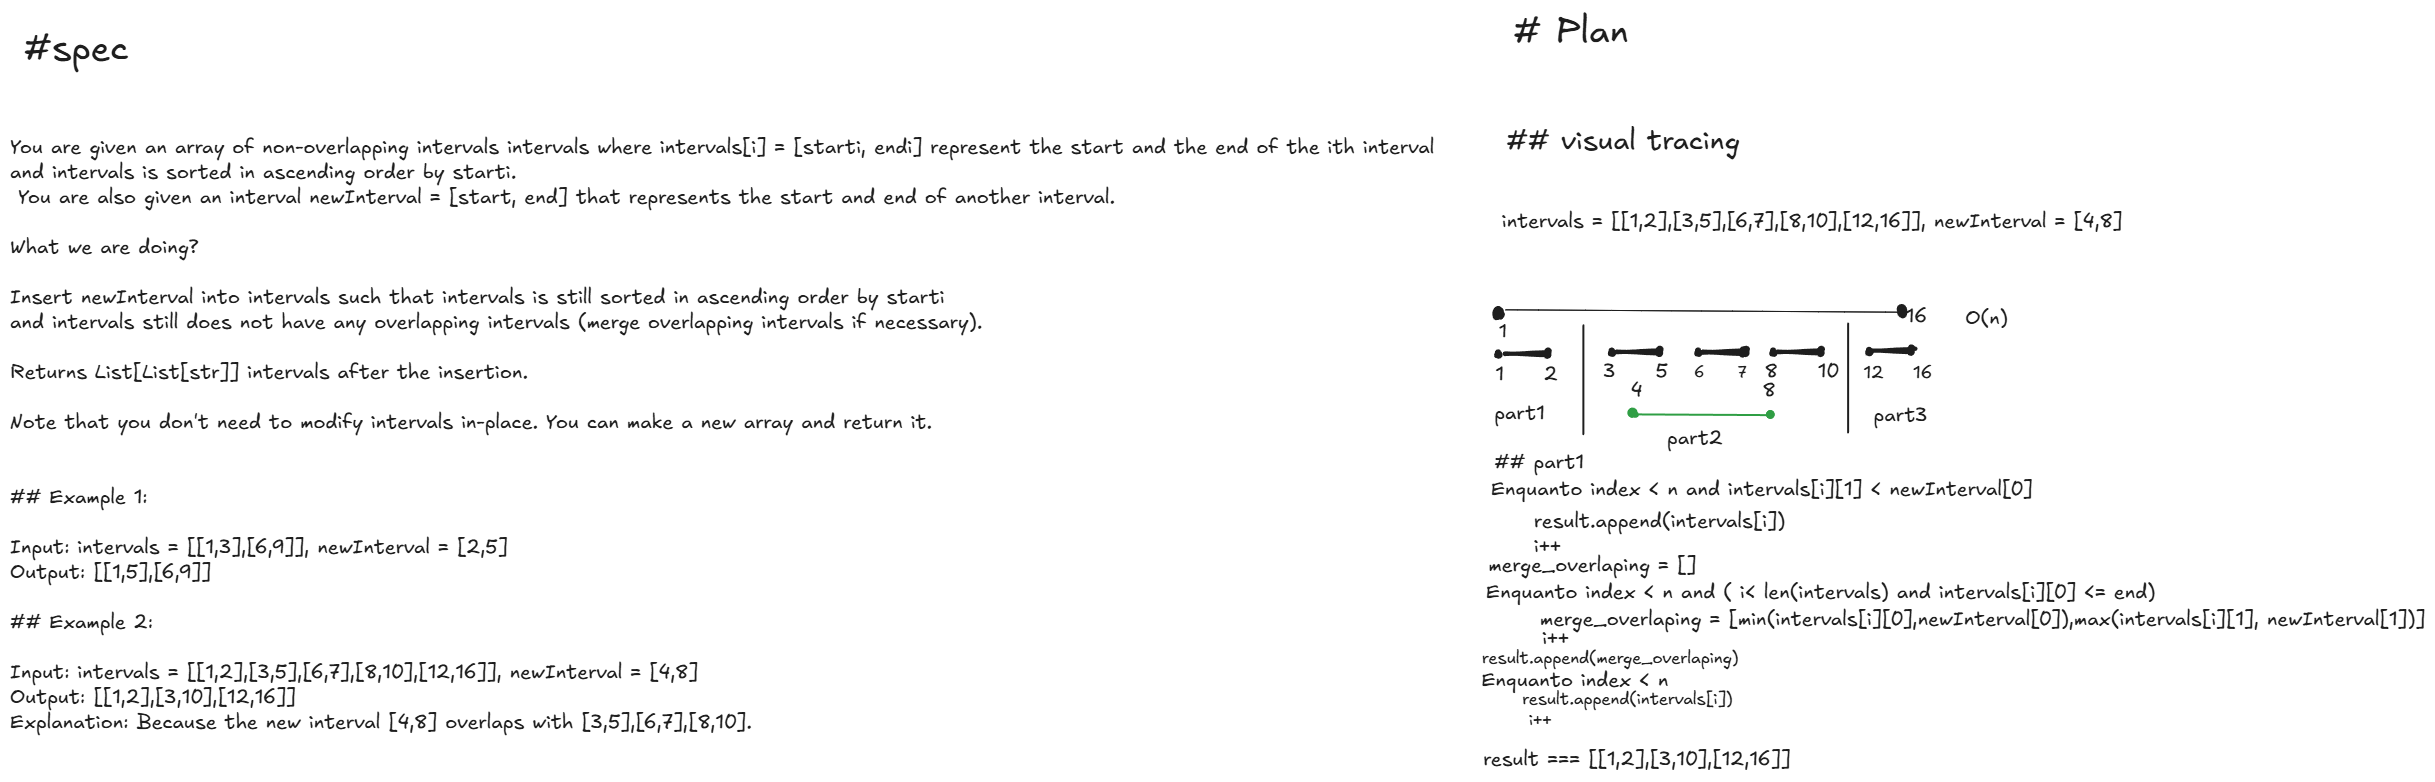

In [ ]:
from typing import List

class Solution:
    def insert(self, intervals: List[List[int]], newInterval: List[int]) -> List[List[int]]:
        """Insert and merge intervals - O(n) time, O(1) space"""
        result = []
        index = 0
        start, end = newInterval
        n = len(intervals)
        # Phase 1: Add all intervals that end before new interval starts
        while index < n and intervals[index][1] < start:
            result.append(intervals[index])
            print(f"Phase 1: Add non-overlapping interval {intervals[index]}")
            index += 1
        
        # Phase 2: Merge overlapping intervals
        while index < n and intervals[index][0] <= end:
            start = min(start, intervals[index][0])
            end = max(end, intervals[index][1])
            index += 1
        
        result.append([start, end])
        result.extend(intervals[index:])
        return result

# Test
sol = Solution()
print("Test 1:")
result = sol.insert([[1,5]], [2,7])
print(f"Result: {result}\n")

print("Test 2:")
result = sol.insert([[1,2],[3,5],[6,9]], [4,8])
print(f"Result: {result}\n")

print("Test 3:")
result = sol.insert([[1,5]], [6,8])
print(f"Result: {result}\n")

## Test Cases

In [ ]:
test_cases = [
    ([[1,5]], [2,7], [[1,7]]),
    ([[1,2],[3,5],[6,9]], [4,8], [[1,2],[3,9]]),
    ([[1,5]], [6,8], [[1,5],[6,8]]),
    ([], [5,7], [[5,7]]),
    ([[1,5],[6,9]], [0,9], [[0,9]]),
    ([[3,5],[6,9]], [1,2], [[1,2],[3,5],[6,9]]),
    ([[1,2],[3,5],[6,7],[8,10],[12,16]], [4,9], [[1,2],[3,10],[12,16]]),
]

print("Testing Insert Interval:")
sol = Solution()
for intervals, new_interval, expected in test_cases:
    # Avoid debug print for cleaner test output
    # Redefine without prints
    pass

# Clean test function
class Solution2:
    def insert(self, intervals: List[List[int]], newInterval: List[int]) -> List[List[int]]:
        result = []
        i = 0
        start, end = newInterval
        
        while i < len(intervals) and intervals[i][1] < start:
            result.append(intervals[i])
            i += 1
        
        while i < len(intervals) and intervals[i][0] <= end:
            start = min(start, intervals[i][0])
            end = max(end, intervals[i][1])
            i += 1
        
        result.append([start, end])
        
        while i < len(intervals):
            result.append(intervals[i])
            i += 1
        
        return result

sol2 = Solution2()
for intervals, new_interval, expected in test_cases:
    result = sol2.insert(intervals, new_interval)
    status = "✓" if result == expected else "✗"
    print(f"{status} insert({intervals}, {new_interval}) → {result}")

## Key Insights

1. **Three distinct regions**: Non-overlapping before, overlapping (merge), non-overlapping after
2. **Overlap condition**: `intervals[i][0] <= end` means overlap exists
3. **Single pass**: O(n) time because each interval is visited once
4. **In-place thinking**: Can be extended to modify original list

## Related Problems
- **Merge Intervals** (easier version)
- **Meeting Rooms II** (use with Meeting Rooms)
- **Data Stream as Disjoint Intervals** (harder version)